In [14]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec

from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
# from scipy.integrate import simps

from numpy import log10, exp

kpc = const.kpc.cgs.value


n_min = 1.04e-02
n_max = 7.52e-02


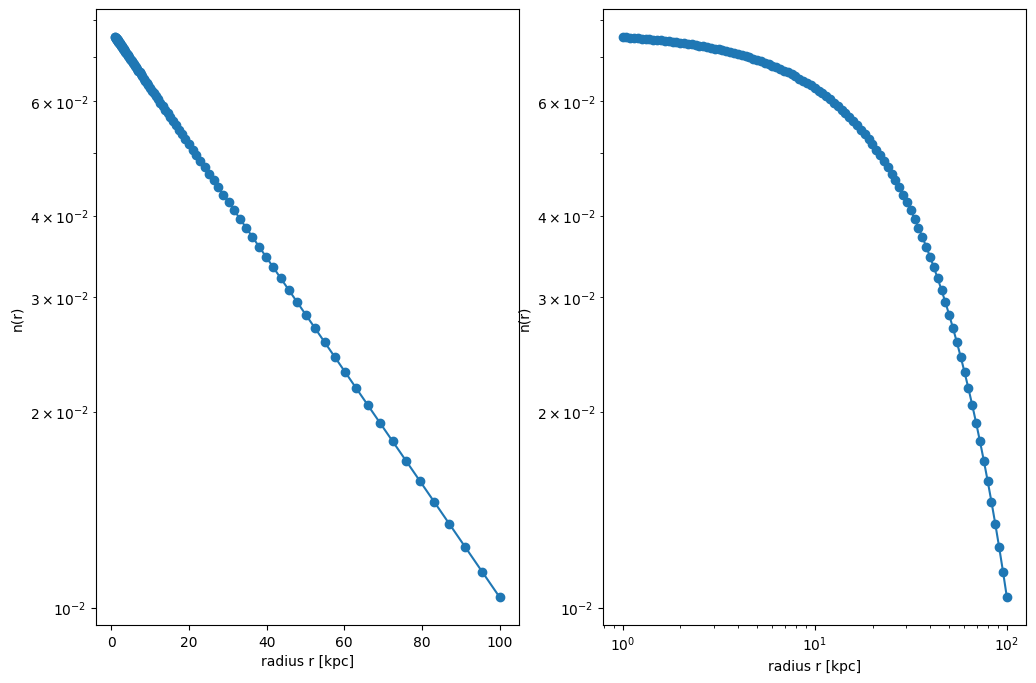

In [15]:
r_in  = 1.0         # [kpc]
r_out = 100.        # [kpc]
r_e   = 0.5*r_out
NHI_total = 1.0e22    # [cm^-2]
file_dlaw = 'dlaw_exp.ini'
#--------------------------------------------------

n0 = 1.0
rr = np.logspace(log10(r_in), log10(r_out), 101)

def nn_exp_func(r, n0, r_e):
    return n0 * np.exp(-r / r_e)

# Scale to match the total H column density
# Analytic solution
n0_analytic = NHI_total / (exp(-r_in/r_e) - exp(-r_out/r_e)) / (r_e*kpc)

# Numerical integration for arbitrary functional form
nn_exp = nn_exp_func(rr, n0, r_e)


integral, _ = quad(lambda r: nn_exp_func(r, 1.0, r_e), r_in, r_out)

# Scale n0 to match total column density
# n0 = NHI_total / (integral * kpc)

# Recalculate the density profile


NHI_integ = (integral * kpc) 
n0 = NHI_total / NHI_integ
nn_exp = n0*exp(-rr/r_e)

fig = plt.figure(1,figsize=(12,8))
# plot with linear-log space
plt.subplot(1,2,1)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.yscale('log')

# plot with linear-log space
plt.subplot(1,2,2)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.xscale('log')
plt.yscale('log')

# Pad one more pixel outside the r_out to include full range 
# that is specified in "radius [r_in, r_out]"
# Purely numerical reason.
rr_pad = r_out * (rr[1]/rr[0])
nn_pad = n0*exp(-rr_pad/r_e)

# Output
# for ii in range(len(rr)):
    # print("continue {:8.5f} {:8.5f}".format(log10(rr[ii]*kpc), log10(nn_exp[ii])))
print(f'n_min = {nn_exp.min():.2e}')
print(f'n_max = {nn_exp.max():.2e}')







In [16]:
nn = np.arange(40,47,0.5)
nn

array([40. , 40.5, 41. , 41.5, 42. , 42.5, 43. , 43.5, 44. , 44.5, 45. ,
       45.5, 46. , 46.5])

In [17]:
from CLOUDY_Function import *

Lumin =45.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
mode = 'WO' # 'WO' - 'W'
# path_way = f'/home/jin/RT/CLOUDY_new_Data/Lum_{Lumin}_{idx}/metal_{metals}/N_H_{multi_factor}_{Column_density_order}/QSO_{mode}'

# warnings.filterwarnings('ignore', category=IntegrationWarning)
# warnings.filterwarnings('ignore', category=AttributeError)

cloudy_data_1 = CLOUDY_data(Lumin,idx_1,metals,Column_density_order)
cloudy_data_2 = CLOUDY_data(Lumin,idx_2,metals,Column_density_order)

print('--'*50)
print(f"Lya Luminosity = {cloudy_data_2[f'Lumin_Lya_{Lumin}_{idx_2}']:.2e} [erg/s]")

print('--'*50)
print(f"C IV Luminosity = {cloudy_data_2[f'Lumin_CIV_{Lumin}_{idx_2}']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data_2[f'Lumin_HeII_{Lumin}_{idx_2}']:.2e} [erg/s]")
print('--'*50)
print(f"C IV Column_density = {cloudy_data_2[f'Column_density_CIV_{Lumin}_{idx_2}']:.2e} [cm-2]")
print(f"He II Column_density = {cloudy_data_2[f'Column_density_HeII_{Lumin}_{idx_2}']:.2e} [cm-2]")
print('--'*50)

----------------------------------------------------------------------------------------------------
Lya Luminosity = 7.47e+43 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Luminosity = 1.85e+43 [erg/s]
HeII Luminosity = 1.69e+43 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Column_density = 2.72e+16 [cm-2]
He II Column_density = 1.45e+18 [cm-2]
----------------------------------------------------------------------------------------------------



     **Luminosity, Emissivity and number density profile**

(1e-15, 0.0001)

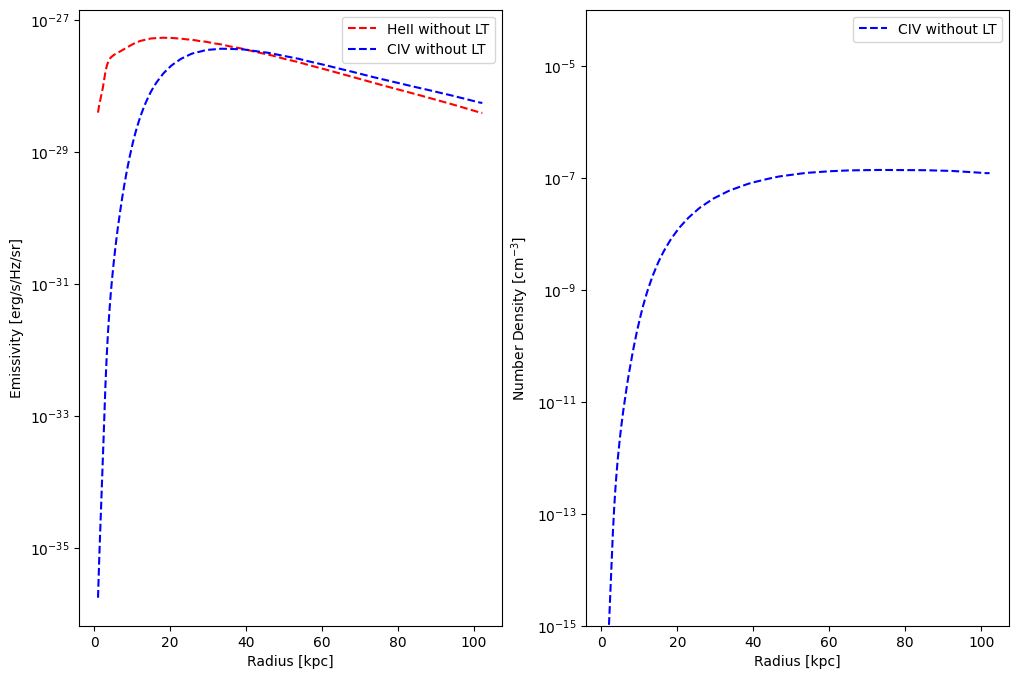

In [18]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)
atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}_{idx_1}'],cloudy_data_1[f'emis_{atom}_{Lumin}_{idx_1}'],'r-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}_{idx_2}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}_{idx_1}'],cloudy_data_1[f'emis_{atom}_{Lumin}_{idx_1}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'emis_{atom}_{Lumin}_{idx_2}'],'b--',label=f'{atom} without LT')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}_{idx_1}'],cloudy_data_1[f'nden_{atom}_{Lumin}_{idx_1}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'nden_{atom}_{Lumin}_{idx_2}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}_{idx_1}'],cloudy_data_1[f'nden_{atom}_{Lumin}_{idx_1}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'nden_{atom}_{Lumin}_{idx_2}'],'b--',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')
plt.legend()

plt.ylim(1e-15,1e-4)

# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'





     **Surface Brightness profile**

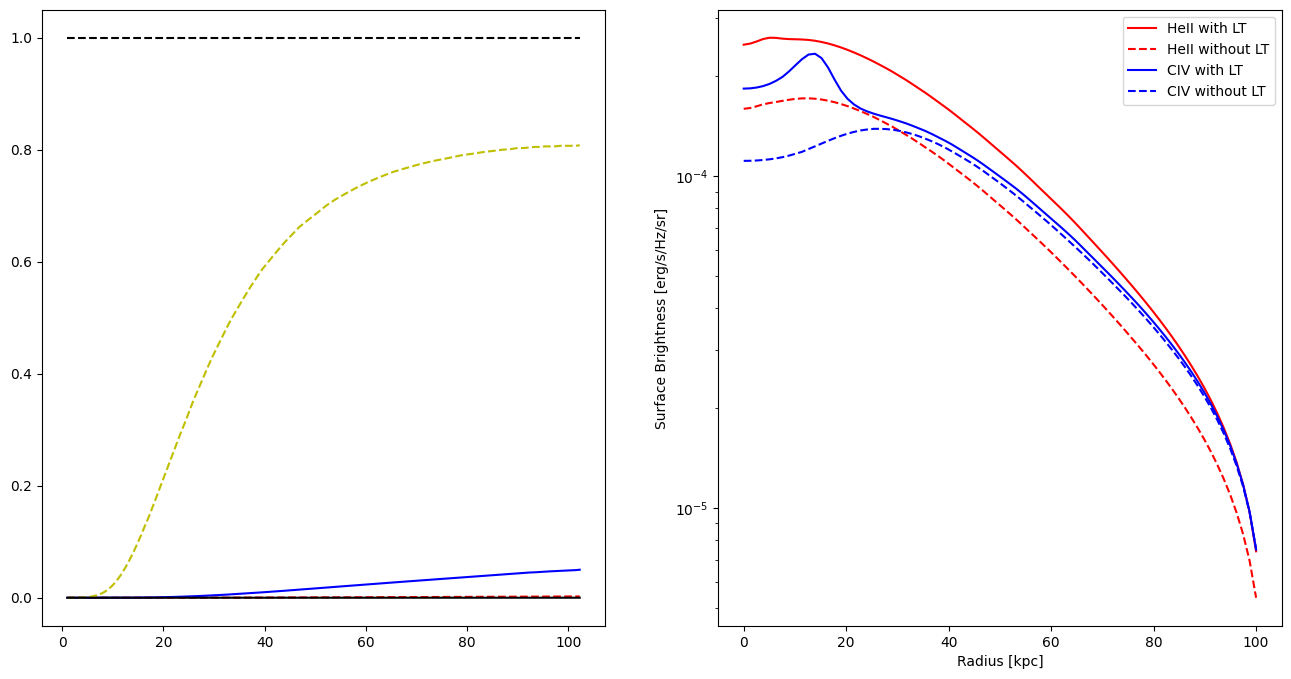

In [19]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(16,8))

plt.subplot(121)
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'frac_CIII_{Lumin}_{idx_2}'],'r--',label=f'C III')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'frac_CIV_{Lumin}_{idx_2}'],'b-',label=f'C IV')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'frac_CV_{Lumin}_{idx_2}'],'y--',label=f'C V')

plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'frac_HI_{Lumin}_{idx_2}'],'k-',label=f'H I')
plt.plot(cloudy_data_2[f'radius_{Lumin}_{idx_2}'],cloudy_data_2[f'frac_HII_{Lumin}_{idx_2}'],'k--',label=f'H II')

# plt.xlim(0,20)

plt.subplot(122)
atom = 'HeII'
plt.plot(cloudy_data_1[f'radius_p_{Lumin}_{idx_1}'],cloudy_data_1[f'SB_{atom}_{Lumin}_{idx_1}'],'r-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_p_{Lumin}_{idx_2}'],cloudy_data_2[f'SB_{atom}_{Lumin}_{idx_2}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
plt.plot(cloudy_data_1[f'radius_p_{Lumin}_{idx_1}'],cloudy_data_1[f'SB_{atom}_{Lumin}_{idx_1}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_p_{Lumin}_{idx_2}'],cloudy_data_2[f'SB_{atom}_{Lumin}_{idx_2}'],'b--',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Surface Brightness [erg/s/Hz/sr]')
plt.yscale('log')
plt.legend()